# 04 — XGBoost (Deep Tuning + Target Encoding)

**Competition:** A Cloned Airbnb Booking Prediction Competition — K353  
**Course:** COMP 468 — Abdullah Gül University

Course-allowed techniques used here:
- **XGBoost** with early stopping, L1/L2 regularisation (Modules 10-11)
- **RandomizedSearchCV** (Modules 7, 10)
- **K-Fold cross-validation** (Module 8)
- **Custom transformer** built on `BaseEstimator + TransformerMixin` (Module 7) — implements a **leakage-free K-Fold Target Encoder** for high-cardinality categoricals.
- **Pipeline + ColumnTransformer** (Module 6)
- **log1p target transform** (a simple data-preprocessing trick; the regressor wrapper that handles it is `TransformedTargetRegressor`).

Outputs:
- `outputs/oof_XGBoost.npy`
- `outputs/submission_xgboost.csv`
- `outputs/xgb_best_params.json`

---

### Outline
1. Setup
2. Load features & decide categorical split
3. **Leakage-free K-Fold Target Encoder** (custom transformer)
4. Preprocessing `ColumnTransformer`
5. Quick XGBoost sanity-baseline
6. RandomizedSearchCV hyperparameter tuning
7. Final 5-fold CV with the best parameters (consistent split with notebook 03 → OOFs are comparable)
8. Refit + Kaggle submission
9. Feature importance

## 1. Setup

In [1]:
import warnings, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
RANDOM_STATE = 42
N_SPLITS = 5

OUT_DIR = Path('../outputs'); OUT_DIR.mkdir(exist_ok=True, parents=True)
print('OUT_DIR =', OUT_DIR.resolve())

OUT_DIR = C:\pprojelerim\Airbnb-K353\outputs


## 2. Load Features & Decide Categorical Split

In [2]:
train_df = pd.read_parquet(OUT_DIR / 'train_features.parquet')
test_df  = pd.read_parquet(OUT_DIR / 'test_features.parquet')

TARGET = 'NumReserveDays2016Q3'
ID_COL = 'PropertyID'
y = train_df[TARGET].astype(float).values
X = train_df.drop(columns=[TARGET, ID_COL])
X_test = test_df.drop(columns=[ID_COL]).reindex(columns=X.columns)
test_ids = test_df[ID_COL].values

# Split categorical columns by cardinality:
#   * high-cardinality → target-encode
#   * low-cardinality  → one-hot
cat_all = X.select_dtypes(exclude='number').columns.tolist()
cardinality = {c: X[c].nunique(dropna=False) for c in cat_all}
HIGH_CARD_THRESHOLD = 15
cat_high = [c for c, n in cardinality.items() if n >  HIGH_CARD_THRESHOLD]
cat_low  = [c for c, n in cardinality.items() if n <= HIGH_CARD_THRESHOLD]
num_cols = X.select_dtypes(include='number').columns.tolist()

print(f'Numeric cols : {len(num_cols)}')
print(f'Cat (high, TE)   : {cat_high}')
print(f'Cat (low, OneHot): {cat_low}')
print('\nCardinalities :', cardinality)

Numeric cols : 130
Cat (high, TE)   : ['PropertyType', 'Neighborhood']
Cat (low, OneHot): ['ListingType', 'MetropolitanStatisticalArea', 'CancellationPolicy']

Cardinalities : {'PropertyType': 27, 'ListingType': 3, 'Neighborhood': 204, 'MetropolitanStatisticalArea': 1, 'CancellationPolicy': 7}


## 3. Leakage-Free K-Fold Target Encoder

We build a custom transformer following the **Module 7 pattern** (`BaseEstimator` + `TransformerMixin`, with `fit`, `transform`, and `fit_transform`).

Why we need the K-fold version:
- A naïve target encoder fit on the entire training set leaks the target into the training features (within-fold leak).
- Solution: when `fit_transform` is called on training data, we compute each row's encoding using a held-out subset of *other* rows (inner K-fold OOF). When `transform` is later called on validation/test data, we use statistics from the **full training set**.
- Because everything happens inside a `Pipeline`, when the outer CV gives us one fold of training data, all of this stays strictly inside that fold — no outer-fold leakage either.

Smoothing: shrink rare-category means toward the global mean, weighted by category count (`smoothing` is the prior weight).

In [3]:
class KFoldTargetEncoder(BaseEstimator, TransformerMixin):
    """Leakage-free K-Fold target encoder for one or more categorical columns.

    Parameters
    ----------
    cols : list[str]
        Column names to encode. They will be REPLACED in the output with the
        smoothed mean-target value (float).
    n_splits : int
        Inner-CV folds used by fit_transform on training data to avoid the
        within-fold target leak.
    smoothing : float
        Bayesian smoothing weight applied toward the global mean.
    random_state : int
    """
    def __init__(self, cols, n_splits=5, smoothing=20.0, random_state=42):
        self.cols = cols
        self.n_splits = n_splits
        self.smoothing = smoothing
        self.random_state = random_state

    # -- core helpers -------------------------------------------------
    def _smoothed_map(self, X_col, y):
        stats = pd.DataFrame({'cat': X_col, 'y': y}).groupby('cat')['y'].agg(['mean', 'count'])
        smoothed = ((stats['count'] * stats['mean'] + self.smoothing * self.global_mean_)
                    / (stats['count'] + self.smoothing))
        return smoothed.to_dict()

    # -- sklearn API --------------------------------------------------
    def fit(self, X, y):
        if not hasattr(y, '__len__'):
            raise ValueError('y is required for target encoding')
        y_arr = np.asarray(y, dtype=float)
        self.global_mean_ = float(y_arr.mean())
        self.maps_ = {c: self._smoothed_map(X[c].astype(str).fillna('__nan__'), y_arr)
                      for c in self.cols}
        return self

    def transform(self, X):
        Xo = X.copy()
        for c in self.cols:
            mapped = X[c].astype(str).fillna('__nan__').map(self.maps_[c])
            Xo[c] = mapped.fillna(self.global_mean_).astype('float32')
        return Xo

    def fit_transform(self, X, y=None, **fit_params):
        """OOF encoding on training data + full-data fit for later transform."""
        y_arr = np.asarray(y, dtype=float)
        self.global_mean_ = float(y_arr.mean())

        Xo = X.copy()
        # init encoded columns
        for c in self.cols:
            Xo[c] = np.full(len(X), self.global_mean_, dtype='float32')

        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)
        for tr_idx, va_idx in kf.split(X):
            for c in self.cols:
                m = self._smoothed_map(
                    X[c].astype(str).fillna('__nan__').iloc[tr_idx],
                    y_arr[tr_idx],
                )
                mapped = X[c].astype(str).fillna('__nan__').iloc[va_idx].map(m)
                Xo.iloc[va_idx, Xo.columns.get_loc(c)] = mapped.fillna(self.global_mean_).astype('float32').values

        # also fit full encoder so .transform() works on val/test
        self.maps_ = {c: self._smoothed_map(X[c].astype(str).fillna('__nan__'), y_arr)
                      for c in self.cols}
        return Xo

    def get_feature_names_out(self, input_features=None):
        return np.array(input_features if input_features is not None else self.cols)

print('KFoldTargetEncoder defined.')

KFoldTargetEncoder defined.


## 4. Preprocessing `ColumnTransformer`
Three branches:
- Numerics → median impute (XGBoost handles missing natively, but we still impute for code consistency).
- Low-card cats → constant-fill + OneHot.
- High-card cats → our `KFoldTargetEncoder`.

In [4]:
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median'))])
cat_low_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
cat_high_pipe = Pipeline([
    ('te', KFoldTargetEncoder(cols=cat_high, n_splits=5, smoothing=20, random_state=RANDOM_STATE)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, num_cols),
    ('cat_low', cat_low_pipe, cat_low),
    ('cat_high', cat_high_pipe, cat_high),
])
print('Preprocessor ready.')

Preprocessor ready.


## 5. Quick XGBoost Sanity-Baseline (untuned)

In [5]:
xgb_base = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# Wrap with TransformedTargetRegressor to learn on log1p(y) and predict back via expm1.
xgb_log_base = TransformedTargetRegressor(
    regressor=xgb_base, func=np.log1p, inverse_func=np.expm1,
)

pipe_base = Pipeline([('prep', preprocessor), ('model', xgb_log_base)])

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
t0 = time.time()
fold_mse = []
for fold, (tr, va) in enumerate(kf.split(X)):
    pipe_base.fit(X.iloc[tr], y[tr])
    pred = np.clip(pipe_base.predict(X.iloc[va]), 0, 92)
    mse = mean_squared_error(y[va], pred)
    fold_mse.append(mse)
    print(f'  fold {fold+1}: MSE = {mse:.3f}')
print(f'Untuned XGB | CV MSE = {np.mean(fold_mse):.3f} ± {np.std(fold_mse):.3f} | {time.time()-t0:.1f}s')

  fold 1: MSE = 219.547


  fold 2: MSE = 243.671


  fold 3: MSE = 232.415


  fold 4: MSE = 222.334


  fold 5: MSE = 228.146
Untuned XGB | CV MSE = 229.223 ± 8.499 | 20.8s


## 6. RandomizedSearchCV Hyperparameter Tuning
Search space covers the most impactful XGBoost knobs (Module 10/11).

In [6]:
from scipy.stats import randint, uniform, loguniform

param_dist = {
    'model__regressor__n_estimators'    : randint(400, 1500),
    'model__regressor__learning_rate'   : loguniform(0.01, 0.1),
    'model__regressor__max_depth'       : randint(3, 10),
    'model__regressor__min_child_weight': randint(1, 10),
    'model__regressor__subsample'       : uniform(0.6, 0.4),     # 0.6 to 1.0
    'model__regressor__colsample_bytree': uniform(0.6, 0.4),
    'model__regressor__gamma'           : uniform(0.0, 0.5),
    'model__regressor__reg_alpha'       : loguniform(1e-3, 1.0),
    'model__regressor__reg_lambda'      : loguniform(0.5, 5.0),
}

search = RandomizedSearchCV(
    estimator=pipe_base,
    param_distributions=param_dist,
    n_iter=25,              # increase for more thorough search
    cv=KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),  # 3-fold to keep time reasonable
    scoring='neg_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=1,               # XGBoost itself parallelises; outer n_jobs=1 avoids RAM blow-up
    verbose=1,
    refit=False,
)

t0 = time.time()
search.fit(X, y)
print(f'\nTuning done in {(time.time()-t0)/60:.1f} min')
best_params = {k.replace('model__regressor__', ''): v for k, v in search.best_params_.items()}
print('Best CV MSE :', -search.best_score_)
print('Best params :', best_params)

with open(OUT_DIR / 'xgb_best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2, default=float)
print('Saved → outputs/xgb_best_params.json')

Fitting 3 folds for each of 25 candidates, totalling 75 fits



Tuning done in 5.4 min
Best CV MSE : 223.44762888445015
Best params : {'colsample_bytree': np.float64(0.8417669517111269), 'gamma': np.float64(0.26992054565083656), 'learning_rate': np.float64(0.01596104142416406), 'max_depth': 7, 'min_child_weight': 7, 'n_estimators': 977, 'reg_alpha': np.float64(0.07465555774745708), 'reg_lambda': np.float64(0.9876514147553049), 'subsample': np.float64(0.6421977039321082)}
Saved → outputs/xgb_best_params.json


## 7. Final 5-Fold CV With Best Parameters
Re-run a clean 5-fold CV using the same split (seed=42) as notebook 03 so the resulting OOFs are directly comparable / blendable.

In [7]:
xgb_best = XGBRegressor(
    **{k: (int(v) if k in ('n_estimators', 'max_depth', 'min_child_weight') else float(v))
       for k, v in best_params.items()},
    tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1,
)
xgb_best_log = TransformedTargetRegressor(
    regressor=xgb_best, func=np.log1p, inverse_func=np.expm1,
)
pipe_best = Pipeline([('prep', preprocessor), ('model', xgb_best_log)])

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
oof = np.zeros(len(y))
fold_mse = []
t0 = time.time()
for fold, (tr, va) in enumerate(kf.split(X)):
    pipe_best.fit(X.iloc[tr], y[tr])
    pred = np.clip(pipe_best.predict(X.iloc[va]), 0, 92)
    oof[va] = pred
    mse = mean_squared_error(y[va], pred)
    fold_mse.append(mse)
    print(f'  fold {fold+1}: MSE = {mse:.3f}')
print(f'\nTuned XGB | CV MSE = {np.mean(fold_mse):.3f} ± {np.std(fold_mse):.3f} | {time.time()-t0:.1f}s')

np.save(OUT_DIR / 'oof_XGBoost.npy', oof)

  fold 1: MSE = 215.653


  fold 2: MSE = 235.243


  fold 3: MSE = 225.798


  fold 4: MSE = 214.323


  fold 5: MSE = 222.847

Tuned XGB | CV MSE = 222.773 ± 7.573 | 31.6s


## 8. Refit on Full Train → Kaggle Submission

In [8]:
pipe_best.fit(X, y)
test_pred = np.clip(pipe_best.predict(X_test), 0, 92)
sub = pd.DataFrame({'Property[Q3]_test': test_ids, 'Pred': test_pred})
out_path = OUT_DIR / 'submission_xgboost.csv'
sub.to_csv(out_path, index=False)
print(f'Saved {out_path.name} | rows={len(sub)} | mean={sub["Pred"].mean():.2f} | '
      f'min={sub["Pred"].min():.2f} max={sub["Pred"].max():.2f}')
sub.head()

Saved submission_xgboost.csv | rows=24318 | mean=13.94 | min=0.00 max=92.00


,Property[Q3]_test,Pred
0,795,0.230452
1,2515,49.069981
2,2595,2.139574
3,5099,27.122040
4,5107,21.665472


## 9. Feature Importance
XGBoost's built-in 'gain' importance — straightforward to interpret.

Top-25 features by gain:
                             feature       gain
         num__q2_unique_reservations 815.580017
               num__q2_reserved_rate 251.316315
           num__ResponseRate_missing 167.458847
                      num__q2_days_R 118.711731
                num__ReviewsPerMonth  72.324280
        num__ResponseTimemin_missing  55.300411
                     num__HasReviews  45.399803
                num__NumberofReviews  26.805281
                  num__recent_booked  18.536203
                   num__q2_booked_m6  18.437550
               num__recent_available  18.101839
            num__recent_booking_rate  14.980597
                 num__WeeklyDiscount  14.898942
          num__recent_available_rate  13.928085
            num__CleaningFee_missing  11.968918
                  num__BusinessReady  11.803586
              num__q2_status_changes   9.670109
               num__h1_reserved_rate   9.517671
                      num__h1_days_R   9.445767
          num__

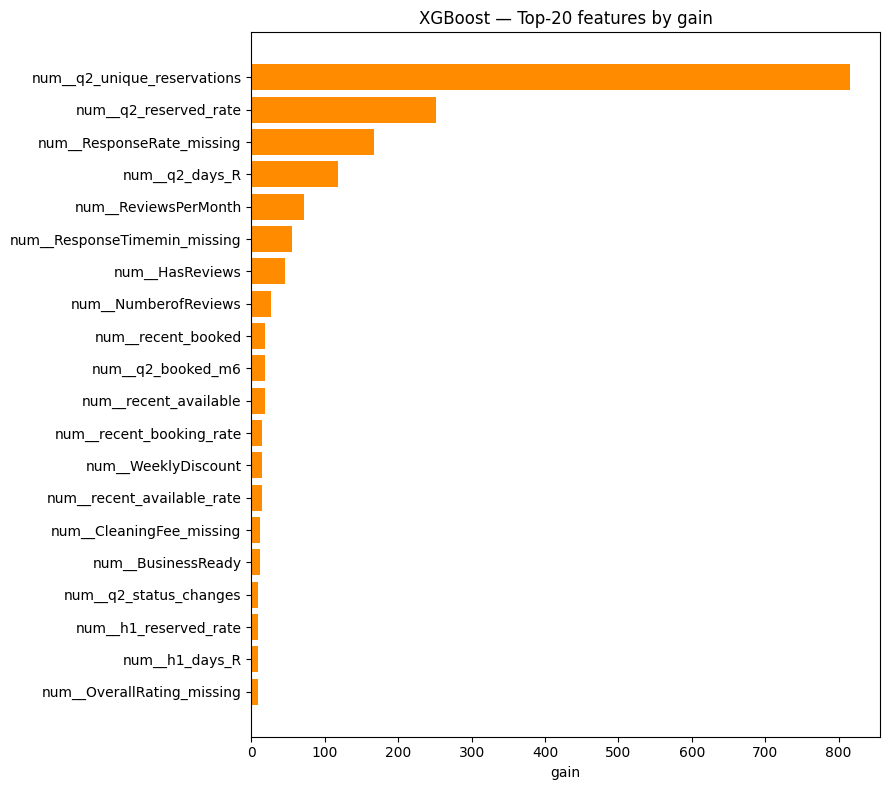

In [9]:
booster = pipe_best.named_steps['model'].regressor_.get_booster()
imp_dict = booster.get_score(importance_type='gain')

# Map XGBoost's f0, f1, ... back to readable feature names from the ColumnTransformer
feature_names = pipe_best.named_steps['prep'].get_feature_names_out()
imp_df = pd.DataFrame({
    'feature': [feature_names[int(k[1:])] if k.startswith('f') and k[1:].isdigit() else k
                for k in imp_dict.keys()],
    'gain': list(imp_dict.values()),
}).sort_values('gain', ascending=False)

print('Top-25 features by gain:')
print(imp_df.head(25).to_string(index=False))

top = imp_df.head(20)[::-1]
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top['feature'], top['gain'], color='darkorange')
ax.set_title('XGBoost — Top-20 features by gain')
ax.set_xlabel('gain')
plt.tight_layout(); plt.savefig(OUT_DIR / 'xgb_feature_importance.png', dpi=120); plt.show()

## Summary
- Custom CV-safe target encoder integrated into the pipeline → no leakage.
- `log1p(y)` smooths the heavy-tail target distribution.
- RandomizedSearchCV explored 25 hyperparameter configs over 3-fold CV.
- Final 5-fold CV uses the same seed as the baselines, so `oof_XGBoost.npy` can be **directly blended** with `oof_GradientBoosting.npy`, `oof_RandomForest.npy`, `oof_DecisionTree.npy` (and later `oof_MLP.npy`) in notebook **06_Blend.ipynb**.

### → Next: `05_MLP_PyTorch.ipynb`
A PyTorch MLP trained with Adam (Module 13). Even if it can't beat XGBoost alone, it usually adds diversity to a blend.